In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import robot_vlp.data_collection.experment_processing as p
import robot_vlp.data_collection.communication as c
import pickle

from robot_vlp.config import EXPERIMENT_DATA_DIR


%load_ext autoreload
%autoreload 2

2024-12-17 09:10:22.071 | INFO     | robot_vlp.config:<module>:11 - PROJ_ROOT path is: /Users/tyrelglass/PhD/Repositories/robot-vlp


In [ ]:
vive_robot_log_clear('vive_test_2.csv')

In [ ]:
vive = c.vive_setup()

In [ ]:
c.read_vive(vive)

In [ ]:
take_vive_cal_point(1, 'vive_test_2.csv', vive)

## Analysis

In [59]:
df= pd.read_csv('vive_test.csv', delimiter = '|')
df = c.parse_vive(df)
df = c.transform_vive_df(df)

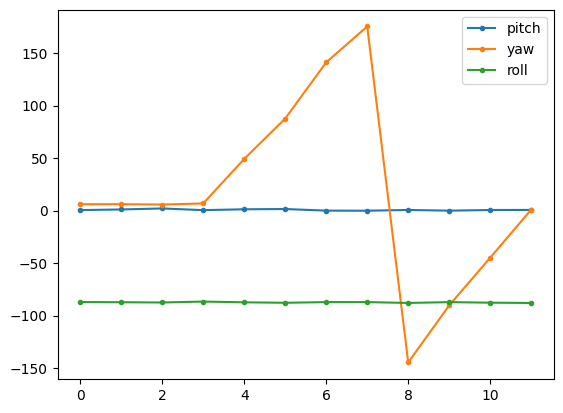

In [60]:
plt.plot(df['vive_pitch'], label = 'pitch', marker = '.')
plt.plot(df['vive_yaw'], label = 'yaw', marker = '.')
plt.plot(df['vive_roll'], label = 'roll', marker = '.')
plt.legend()

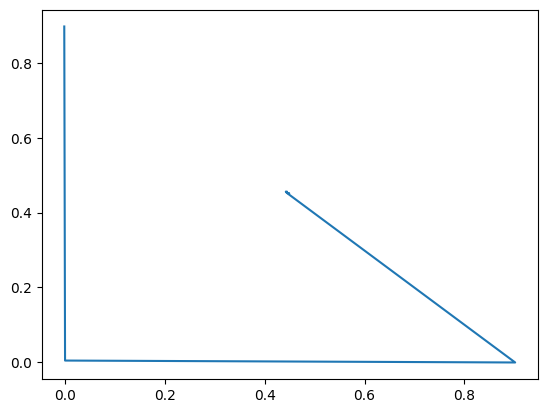

In [61]:
plt.plot(df['vive_x'], df['vive_z'])

In [ ]:
transformer = c.ViveToRobotTransform()
transformer.derive_transform(df)

last_vive_point = c.get_last_vive_position('vive_test.csv')
transformed_point = transformer.transform_pose(c.add_bottom_row(last_vive_point))
vive_x, vive_y, vive_z , vive_pitch, vive_yaw, vive_roll = c.extract_pose_y_up(transformed_point)

In [ ]:


robot_x = vive_x + 0.067*np.sin(vive_yaw/180*np.pi)
robot_y = vive_y + 0.067*np.cos(vive_yaw/180*np.pi)

In [79]:
df['vlp_x'] = df['vive_x'] +0.08*np.sin(df['vive_yaw']/180*np.pi)
df['vlp_z'] = df['vive_z'] +0.08*np.cos(df['vive_yaw']/180*np.pi)

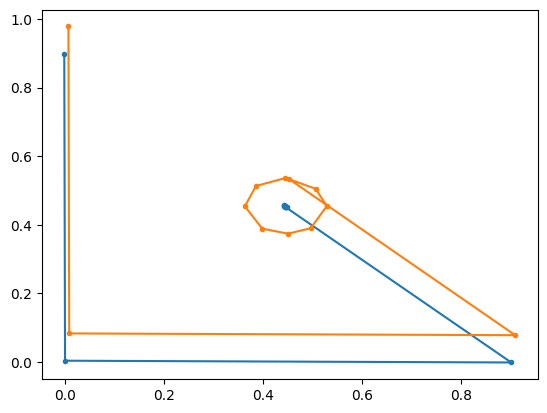

In [83]:
plt.plot(df['vive_x'], df['vive_z'], marker = '.')
plt.plot(df['vlp_x'], df['vlp_z'], marker = '.')